# Träningsanalys

## Syfte

Det här projektet analyserar träningsdata från styrketräning.

Programmet läser in träningsdata från en CSV-fil och analyserar
bland annat träningsvolym, viktutveckling och träningsfrekvens.

Resultatet presenteras med statistik och visualiseringar.

Projektet visar hur Python kan användas för att läsa in,
bearbeta, analysera och visualisera data. Dessa delar är
relevanta inom AI- och datautveckling eftersom datadrivna
system kräver strukturerad datahantering och analys.

In [1]:
import csv

filnamn = "training_data.csv"

with open(filnamn, "r", encoding="utf-8") as fil:
    lasare = csv.DictReader(fil)
    traningsdata = list(lasare)

print(traningsdata)

[{'datum': '2026-09-01', 'ovning': 'Bänkpress', 'vikt': '70.0', 'reps': '10', 'set': '3'}, {'datum': '2026-09-03', 'ovning': 'Bänkpress', 'vikt': '72.5', 'reps': '8', 'set': '3'}, {'datum': '2026-09-05', 'ovning': 'Knäböj', 'vikt': '90.0', 'reps': '8', 'set': '3'}, {'datum': '2026-09-07', 'ovning': 'Bänkpress', 'vikt': '75.0', 'reps': '6', 'set': '3'}, {'datum': '2026-09-09', 'ovning': 'Knäböj', 'vikt': '95.0', 'reps': '6', 'set': '3'}, {'datum': '2026-09-11', 'ovning': 'Marklyft', 'vikt': '120.0', 'reps': '5', 'set': '3'}, {'datum': '2026-09-13', 'ovning': 'Bänkpress', 'vikt': '77.5', 'reps': '5', 'set': '3'}, {'datum': '2026-09-15', 'ovning': 'Knäböj', 'vikt': '100.0', 'reps': '5', 'set': '3'}, {'datum': '2026-09-17', 'ovning': 'Marklyft', 'vikt': '125.0', 'reps': '4', 'set': '3'}, {'datum': '2026-09-19', 'ovning': 'Bänkpress', 'vikt': '80.0', 'reps': '4', 'set': '3'}, {'datum': '2026-09-21', 'ovning': 'Knäböj', 'vikt': '102.5', 'reps': '4', 'set': '3'}, {'datum': '2026-09-23', 'ovni

## Bearbetning av data

CSV-filer läser in värden som text. Därför behöver numeriska
värden omvandlas till rätt datatyper innan vi kan göra
beräkningar.

Vikt omvandlas till `float` eftersom vikten kan innehålla
decimaler. Repetitioner och antal set omvandlas till `int`
eftersom de är heltal.


In [2]:
for rad in traningsdata:
    rad["vikt"] = float(rad["vikt"])
    rad["reps"] = int(rad["reps"])
    rad["set"] = int(rad["set"])

print(traningsdata[0])

{'datum': '2026-09-01', 'ovning': 'Bänkpress', 'vikt': 70.0, 'reps': 10, 'set': 3}


In [3]:
print(type(traningsdata[0]["datum"]))
print(type(traningsdata[0]["ovning"]))
print(type(traningsdata[0]["vikt"]))
print(type(traningsdata[0]["reps"]))
print(type(traningsdata[0]["set"]))

<class 'str'>
<class 'str'>
<class 'float'>
<class 'int'>
<class 'int'>


## Beräkning av träningsvolym

Träningsvolym beräknas genom att multiplicera vikt med antal
repetitioner och antal set.

Formeln är:

**träningsvolym = vikt × reps × set**

Exempel:

70 kg × 10 reps × 3 set = 2100 kg

In [4]:
def berakna_volym(vikt, reps, antal_set):
    volym = vikt * reps * antal_set
    return volym

In [5]:
volym = berakna_volym(70.0, 10, 3)

print(volym)

2100.0


## Träningsvolym för alla träningspass

Nu använder vi funktionen `berakna_volym` på alla rader i
träningsdatan.

För varje träningspass beräknas träningsvolymen och resultatet
sparas i en ny kolumn som heter `volym`.

In [6]:
for rad in traningsdata:
    rad["volym"] = berakna_volym(
        rad["vikt"],
        rad["reps"],
        rad["set"]
    )

print(traningsdata[0])


{'datum': '2026-09-01', 'ovning': 'Bänkpress', 'vikt': 70.0, 'reps': 10, 'set': 3, 'volym': 2100.0}


In [7]:
for rad in traningsdata:
    print(
        rad["datum"],
        "-",
        rad["ovning"],
        "-",
        rad["volym"],
        "kg"
    )

2026-09-01 - Bänkpress - 2100.0 kg
2026-09-03 - Bänkpress - 1740.0 kg
2026-09-05 - Knäböj - 2160.0 kg
2026-09-07 - Bänkpress - 1350.0 kg
2026-09-09 - Knäböj - 1710.0 kg
2026-09-11 - Marklyft - 1800.0 kg
2026-09-13 - Bänkpress - 1162.5 kg
2026-09-15 - Knäböj - 1500.0 kg
2026-09-17 - Marklyft - 1500.0 kg
2026-09-19 - Bänkpress - 960.0 kg
2026-09-21 - Knäböj - 1230.0 kg
2026-09-23 - Marklyft - 1170.0 kg


## Total träningsvolym

För att få en överblick över träningen beräknar vi den
totala träningsvolymen.

Funktionen går igenom alla träningspass med en for-loop
och summerar värdet från kolumnen volym.

Resultatet returneras som ett tal.

In [9]:
def berakna_total_volym(data):
    total_volym = 0

    for rad in data:
        total_volym += rad["volym"]

    return total_volym

In [10]:
total_volym = berakna_total_volym(traningsdata)

print("Total träningsvolym:", total_volym, "kg")

Total träningsvolym: 18382.5 kg


## Filtrera träningsdata efter övning

För att kunna analysera en specifik övning skapar vi en funktion
som filtrerar träningsdatan.

Funktionen tar träningsdata och namnet på en övning som
parametrar och returnerar endast de träningspass som
tillhör den valda övningen.

In [11]:
def filtrera_ovning(data, vald_ovning):
    filtrerad_data = []

    for rad in data:
        if rad["ovning"] == vald_ovning:
            filtrerad_data.append(rad)

    return filtrerad_data

In [12]:
bankpress_data = filtrera_ovning(traningsdata, "Bänkpress")

print("Antal Bänkpress-pass:", len(bankpress_data))

for rad in bankpress_data:
    print(rad["datum"], "-", rad["vikt"], "kg")

Antal Bänkpress-pass: 5
2026-09-01 - 70.0 kg
2026-09-03 - 72.5 kg
2026-09-07 - 75.0 kg
2026-09-13 - 77.5 kg
2026-09-19 - 80.0 kg


## Högsta vikt

Vi skapar en funktion som hittar den högsta använda vikten
i den valda träningsdatan.

Det gör det möjligt att identifiera den högsta registrerade
vikten för en övning.

In [13]:
def hitta_maxvikt(data):
    maxvikt = 0

    for rad in data:
        if rad["vikt"] > maxvikt:
            maxvikt = rad["vikt"]

    return maxvikt

In [14]:
maxvikt_bankpress = hitta_maxvikt(bankpress_data)

print("Högsta Bänkpress-vikt:", maxvikt_bankpress, "kg")

Högsta Bänkpress-vikt: 80.0 kg


## Personligt rekord

Vi använder en boolesk variabel för att markera om en
träningsrad innehåller den högsta registrerade vikten
för den valda övningen.

Värdet kan vara `True` eller `False`.

In [15]:
for rad in bankpress_data:
    personligt_rekord = rad["vikt"] == maxvikt_bankpress

    print(
        rad["datum"],
        "-",
        rad["vikt"],
        "kg - Personligt rekord:",
        personligt_rekord
    )

2026-09-01 - 70.0 kg - Personligt rekord: False
2026-09-03 - 72.5 kg - Personligt rekord: False
2026-09-07 - 75.0 kg - Personligt rekord: False
2026-09-13 - 77.5 kg - Personligt rekord: False
2026-09-19 - 80.0 kg - Personligt rekord: True


## Felhantering

Programmet använder `try` och `except` för att hantera
problem när träningsfilen läses in.

Om CSV-filen inte kan hittas visas ett tydligt felmeddelande
istället för att programmet avslutas med ett obegripligt
felmeddelande.

In [16]:
def lasa_traningsdata(filnamn):
    try:
        with open(filnamn, "r", encoding="utf-8") as fil:
            lasare = csv.DictReader(fil)
            data = list(lasare)

        return data

    except FileNotFoundError:
        print("Fel: Träningsfilen kunde inte hittas.")
        return []

In [17]:
test_data = lasa_traningsdata("training_data.csv")

print("Antal träningsrader:", len(test_data))

Antal träningsrader: 12


In [18]:
fel_test = lasa_traningsdata("fil_som_inte_finns.csv")

print("Antal rader:", len(fel_test))

Fel: Träningsfilen kunde inte hittas.
Antal rader: 0


## Objektorienterad programmering

Vi använder en klass för att representera ett träningspass.

Klassen `Träningspass` innehåller information om datum, övning,
vikt, repetitioner och antal set.

Klassen har även en metod som beräknar träningsvolymen.

På så sätt samlar vi data och funktionalitet som hör ihop
i samma objekt.

In [19]:
class Traningspass:
    def __init__(self, datum, ovning, vikt, reps, antal_set):
        self.datum = datum
        self.ovning = ovning
        self.vikt = vikt
        self.reps = reps
        self.antal_set = antal_set

    def berakna_volym(self):
        return self.vikt * self.reps * self.antal_set

In [20]:
pass1 = Traningspass(
    "2026-09-01",
    "Bänkpress",
    70.0,
    10,
    3
)

print(pass1.ovning)
print(pass1.vikt)
print(pass1.berakna_volym())

Bänkpress
70.0
2100.0


## Arv med inheritance

Vi skapar en underklass som heter `Styrkepass`.

`Styrkepass` ärver från klassen `Traningspass`.
Det innebär att den får klassens attribut och metoder.

Vi lägger dessutom till ett eget attribut som beskriver
vilken typ av styrkepass det är.

In [21]:
class Styrkepass(Traningspass):
    def __init__(self, datum, ovning, vikt, reps, antal_set, muskelgrupp):
        super().__init__(datum, ovning, vikt, reps, antal_set)
        self.muskelgrupp = muskelgrupp

In [22]:
styrkepass1 = Styrkepass(
    "2026-09-19",
    "Bänkpress",
    80.0,
    4,
    3,
    "Bröst"
)

print(styrkepass1.ovning)
print(styrkepass1.vikt)
print(styrkepass1.muskelgrupp)
print(styrkepass1.berakna_volym())

Bänkpress
80.0
Bröst
960.0


## Skapa träningsobjekt

Nu omvandlar vi träningsraderna från CSV-filen till objekt av
klassen `Traningspass`.

På så sätt kan vi använda objektorienterad programmering
tillsammans med den data som programmet har läst in från CSV-filen.

In [23]:
traningsobjekt = []

for rad in traningsdata:
    pass_objekt = Traningspass(
        rad["datum"],
        rad["ovning"],
        rad["vikt"],
        rad["reps"],
        rad["set"]
    )

    traningsobjekt.append(pass_objekt)

print("Antal träningsobjekt:", len(traningsobjekt))

Antal träningsobjekt: 12


In [24]:
for pass_objekt in traningsobjekt[:3]:
    print(
        pass_objekt.datum,
        "-",
        pass_objekt.ovning,
        "-",
        pass_objekt.vikt,
        "kg",
        "- volym:",
        pass_objekt.berakna_volym(),
        "kg"
    )

2026-09-01 - Bänkpress - 70.0 kg - volym: 2100.0 kg
2026-09-03 - Bänkpress - 72.5 kg - volym: 1740.0 kg
2026-09-05 - Knäböj - 90.0 kg - volym: 2160.0 kg


## Skapa träningsobjekt

Nu omvandlar vi träningsraderna från CSV-filen till objekt av
klassen `Traningspass`.

På så sätt kan vi använda objektorienterad programmering
tillsammans med den data som programmet har läst in från CSV-filen.


In [ ]:
traningsobjekt = []

for rad in traningsdata:
    pass_objekt = Traningspass(
        rad["datum"],
        rad["ovning"],
        rad["vikt"],
        rad["reps"],
        rad["set"]
    )

    traningsobjekt.append(pass_objekt)

print("Antal träningsobjekt:", len(traningsobjekt))

In [25]:
for pass_objekt in traningsobjekt[:3]:
    print(
        pass_objekt.datum,
        "-",
        pass_objekt.ovning,
        "-",
        pass_objekt.vikt,
        "kg",
        "- volym:",
        pass_objekt.berakna_volym(),
        "kg"
    )

2026-09-01 - Bänkpress - 70.0 kg - volym: 2100.0 kg
2026-09-03 - Bänkpress - 72.5 kg - volym: 1740.0 kg
2026-09-05 - Knäböj - 90.0 kg - volym: 2160.0 kg


## Analysera träningsvolym per övning

Nu analyserar vi hur stor träningsvolym som har genomförts för
varje övning.

Det gör det möjligt att jämföra träningsmängden mellan olika övningar.

In [26]:
def berakna_volym_per_ovning(data):
    volym_per_ovning = {}

    for rad in data:
        ovning = rad["ovning"]
        volym = rad["volym"]

        if ovning not in volym_per_ovning:
            volym_per_ovning[ovning] = 0

        volym_per_ovning[ovning] += volym

    return volym_per_ovning

In [27]:
volym_per_ovning = berakna_volym_per_ovning(traningsdata)

print(volym_per_ovning)

{'Bänkpress': 7312.5, 'Knäböj': 6600.0, 'Marklyft': 4470.0}


In [28]:
hogsta_volym = 0
ovning_med_hogst_volym = ""

for ovning, volym in volym_per_ovning.items():
    if volym > hogsta_volym:
        hogsta_volym = volym
        ovning_med_hogst_volym = ovning

print("Övning med högst träningsvolym:", ovning_med_hogst_volym)
print("Träningsvolym:", hogsta_volym, "kg")

Övning med högst träningsvolym: Bänkpress
Träningsvolym: 7312.5 kg


In [29]:
def rakna_pass_per_ovning(data):
    antal_pass = {}

    for rad in data:
        ovning = rad["ovning"]

        if ovning not in antal_pass:
            antal_pass[ovning] = 0

        antal_pass[ovning] += 1

    return antal_pass

In [30]:
pass_per_ovning = rakna_pass_per_ovning(traningsdata)

print(pass_per_ovning)

{'Bänkpress': 5, 'Knäböj': 4, 'Marklyft': 3}


## Beräkna genomsnittlig vikt

Nu beräknar vi den genomsnittliga vikten för en viss övning.

Det gör det möjligt att jämföra den genomsnittliga belastningen
mellan olika övningar.

In [31]:
def berakna_genomsnittlig_vikt(data):
    if len(data) == 0:
        return 0

    total_vikt = 0

    for rad in data:
        total_vikt += rad["vikt"]

    genomsnitt = total_vikt / len(data)

    return genomsnitt

In [32]:
genomsnitt_bankpress = berakna_genomsnittlig_vikt(bankpress_data)

print("Genomsnittlig Bänkpress-vikt:", genomsnitt_bankpress, "kg")

Genomsnittlig Bänkpress-vikt: 75.0 kg


## Samlad analys av en övning

Nu kombinerar vi flera av programmets analyser i en funktion.

Funktionen visar antal träningspass, högsta vikt och genomsnittlig vikt
för en vald övning.

In [35]:
def analysera_ovning(data, vald_ovning):
    ovning_data = filtrera_ovning(data, vald_ovning)

    if len(ovning_data) == 0:
        return None

    antal_pass = len(ovning_data)
    hogsta_vikt = hitta_maxvikt(ovning_data)
    genomsnittlig_vikt = berakna_genomsnittlig_vikt(ovning_data)

    return {
        "ovning": vald_ovning,
        "antal_pass": antal_pass,
        "hogsta_vikt": hogsta_vikt,
        "genomsnittlig_vikt": genomsnittlig_vikt
    }

In [36]:
analys_bankpress = analysera_ovning(traningsdata, "Bänkpress")

print(analys_bankpress)

{'ovning': 'Bänkpress', 'antal_pass': 5, 'hogsta_vikt': 80.0, 'genomsnittlig_vikt': 75.0}


In [37]:
def analysera_ovning(data, vald_ovning):
    ovning_data = filtrera_ovning(data, vald_ovning)

    if len(ovning_data) == 0:
        return None

    antal_pass = len(ovning_data)
    hogsta_vikt = hitta_maxvikt(ovning_data)
    genomsnittlig_vikt = berakna_genomsnittlig_vikt(ovning_data)

    return {
        "ovning": vald_ovning,
        "antal_pass": antal_pass,
        "hogsta_vikt": hogsta_vikt,
        "genomsnittlig_vikt": genomsnittlig_vikt
    }

In [38]:
analys_bankpress = analysera_ovning(traningsdata, "Bänkpress")

print(analys_bankpress)

{'ovning': 'Bänkpress', 'antal_pass': 5, 'hogsta_vikt': 80.0, 'genomsnittlig_vikt': 75.0}


In [40]:
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [41]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.1 MB/s eta 0:00:09
   -- ------------------------------------- 0.5/9.5 MB 1.1 MB/s eta 0:00:09
   --- ------------------------------------ 0.8/9.5 MB 791.3 kB/s eta 0:00:12
   --- ------------------------------------ 0.8/9.5 MB 791.3 kB/s eta 0:00:12
   ---- ----------------------------------- 1.0/9.5 MB 668.4 kB/s eta 0:00:13
   ----- ---------------------------------- 1.3/9.5 MB 736.5 kB/s eta 0:00:12
   ----- ---------------------------------- 1.3/9.5 MB 736.5 kB/s eta 0:00:12
   ------ --------------------------------- 1.6/9.5 MB 726.8 kB/s eta 0:00:11
   ------- -------------------------------- 1.8/9.5 MB 776.8 kB/s eta 0:00:10
   ------- -------------------------------- 1.8/9.5 MB 776.8 kB/s eta 0:00:10
   -------- -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [42]:
import matplotlib.pyplot as plt

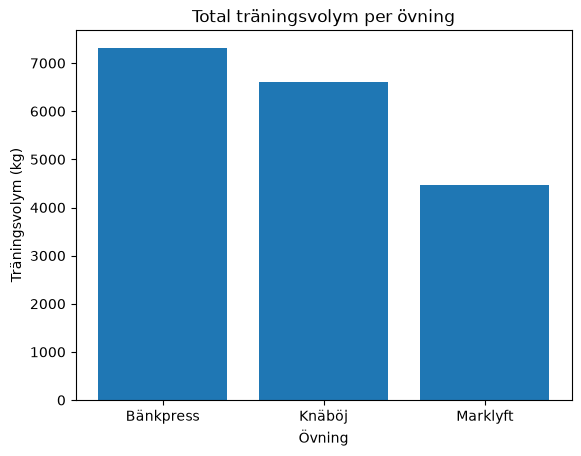

In [43]:
ovningar = list(volym_per_ovning.keys())
volymer = list(volym_per_ovning.values())

plt.bar(ovningar, volymer)

plt.title("Total träningsvolym per övning")
plt.xlabel("Övning")
plt.ylabel("Träningsvolym (kg)")

plt.show()

## Viktutveckling över tid

Nu visualiserar vi hur vikten i Bänkpress har förändrats
under träningsperioden.

Det gör det lättare att se utvecklingen över tid.

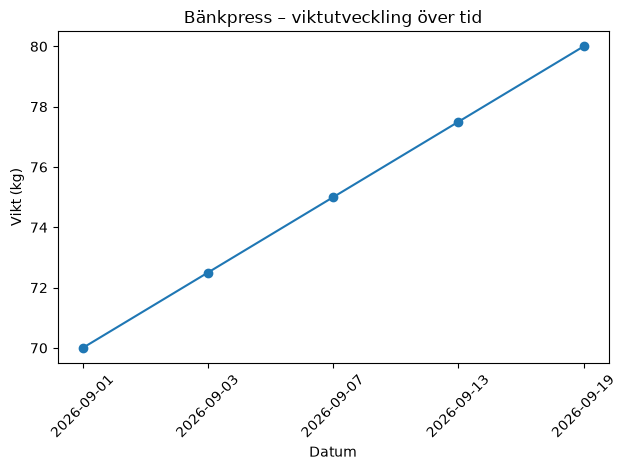

In [44]:
bankpress_datum = []
bankpress_vikter = []

for rad in bankpress_data:
    bankpress_datum.append(rad["datum"])
    bankpress_vikter.append(rad["vikt"])

plt.plot(bankpress_datum, bankpress_vikter, marker="o")

plt.title("Bänkpress – viktutveckling över tid")
plt.xlabel("Datum")
plt.ylabel("Vikt (kg)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [45]:
plt.savefig("bankpress_utveckling.png")

<Figure size 640x480 with 0 Axes>

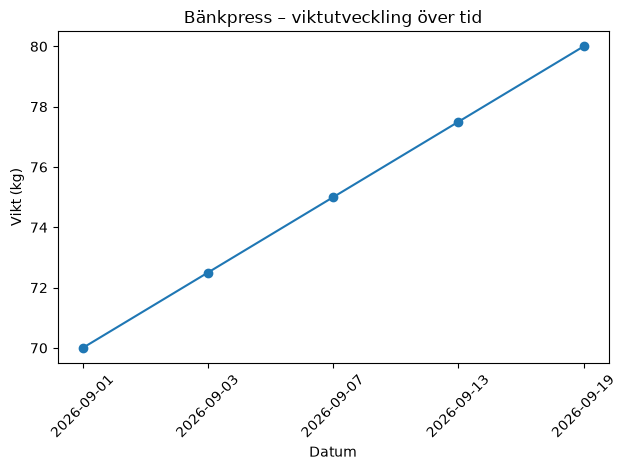

In [46]:
plt.plot(bankpress_datum, bankpress_vikter, marker="o")

plt.title("Bänkpress – viktutveckling över tid")
plt.xlabel("Datum")
plt.ylabel("Vikt (kg)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("bankpress_utveckling.png")

plt.show()

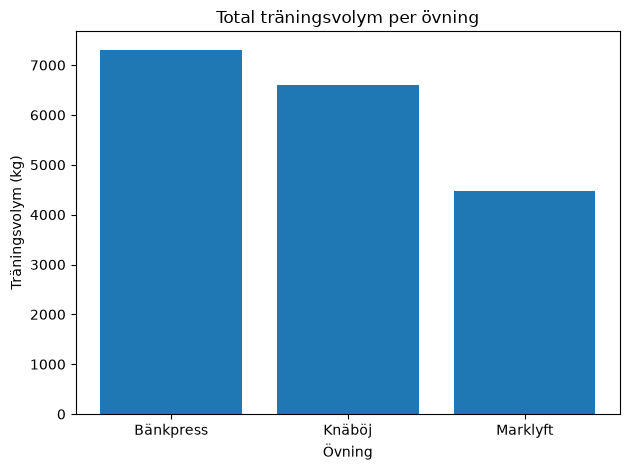

In [47]:
plt.bar(ovningar, volymer)

plt.title("Total träningsvolym per övning")
plt.xlabel("Övning")
plt.ylabel("Träningsvolym (kg)")

plt.tight_layout()

plt.savefig("traningsvolym_per_ovning.png")

plt.show()

In [48]:
for ovning, volym in volym_per_ovning.items():
    print(ovning, "-", volym, "kg")

Bänkpress - 7312.5 kg
Knäböj - 6600.0 kg
Marklyft - 4470.0 kg


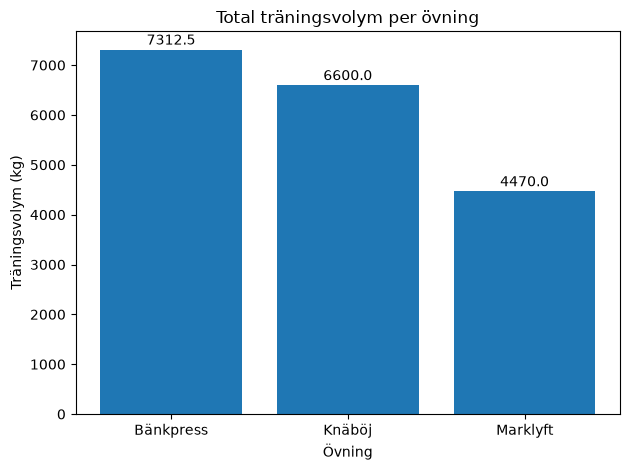

In [49]:
plt.bar(ovningar, volymer)

plt.title("Total träningsvolym per övning")
plt.xlabel("Övning")
plt.ylabel("Träningsvolym (kg)")

for i, volym in enumerate(volymer):
    plt.text(i, volym + 100, f"{volym:.1f}", ha="center")

plt.tight_layout()
plt.savefig("traningsvolym_per_ovning.png")
plt.show()

In [50]:
for rad in bankpress_data:
    print(rad["datum"], "-", rad["vikt"], "kg")

2026-09-01 - 70.0 kg
2026-09-03 - 72.5 kg
2026-09-07 - 75.0 kg
2026-09-13 - 77.5 kg
2026-09-19 - 80.0 kg


In [51]:
forsta_vikt = bankpress_data[0]["vikt"]
senaste_vikt = bankpress_data[-1]["vikt"]

okning = senaste_vikt - forsta_vikt

print("Första vikt:", forsta_vikt, "kg")
print("Senaste vikt:", senaste_vikt, "kg")
print("Total ökning:", okning, "kg")

Första vikt: 70.0 kg
Senaste vikt: 80.0 kg
Total ökning: 10.0 kg


## Hantera datum

Träningsdatumen är just nu textsträngar. Vi omvandlar dem till
datumobjekt med hjälp av Pythons standardbibliotek `datetime`.

Det gör det möjligt att arbeta mer korrekt med datum och tidsperioder.

In [52]:
from datetime import datetime

In [53]:
for rad in traningsdata:
    rad["datum"] = datetime.strptime(rad["datum"], "%Y-%m-%d").date()

print(traningsdata[0]["datum"])
print(type(traningsdata[0]["datum"]))

2026-09-01
<class 'datetime.date'>


## Träningsperiod

Nu använder vi datumobjekten för att räkna ut hur många dagar
som träningsdatan sträcker sig över.

In [54]:
forsta_datum = min(rad["datum"] for rad in traningsdata)
senaste_datum = max(rad["datum"] for rad in traningsdata)

traningsperiod = senaste_datum - forsta_datum

print("Första träningsdatum:", forsta_datum)
print("Senaste träningsdatum:", senaste_datum)
print("Träningsperiod:", traningsperiod.days, "dagar")

Första träningsdatum: 2026-09-01
Senaste träningsdatum: 2026-09-23
Träningsperiod: 22 dagar


## Träningsfrekvens per vecka

Nu använder vi träningsperioden och antalet träningspass
för att uppskatta hur många träningspass som genomförts per vecka.

In [55]:
antal_traningspass = len(traningsdata)

antal_veckor = traningsperiod.days / 7

pass_per_vecka = antal_traningspass / antal_veckor

print("Antal träningspass:", antal_traningspass)
print("Träningsperiod:", traningsperiod.days, "dagar")
print("Genomsnittliga pass per vecka:", round(pass_per_vecka, 2))

Antal träningspass: 12
Träningsperiod: 22 dagar
Genomsnittliga pass per vecka: 3.82


In [6]:
import csv

In [4]:
def lasa_traningsdata_sakert(filnamn):
    try:
        with open(filnamn, "r", encoding="utf-8") as fil:
            lasare = csv.DictReader(fil)
            data = list(lasare)

        if not data:
            print("Fel: CSV-filen är tom.")
            return []

        for rad in data:
            rad["vikt"] = float(rad["vikt"])
            rad["reps"] = int(rad["reps"])
            rad["set"] = int(rad["set"])

        return data

    except FileNotFoundError:
        print(f"Fel: Filen '{filnamn}' kunde inte hittas.")
        return []

    except ValueError:
        print(
            f"Fel: Filen '{filnamn}' innehåller ett ogiltigt "
            "numeriskt värde."
        )
        return []

    except KeyError as fel:
        print(
            f"Fel: CSV-filen saknar den förväntade kolumnen {fel}."
        )
        return []

    except OSError:
        print(f"Fel: Kunde inte läsa filen '{filnamn}'.")
        return []

In [7]:
test_data = lasa_traningsdata_sakert("training_data.csv")

print("Antal rader:", len(test_data))

Antal rader: 12


In [8]:
felaktig_data = [
    {
        "datum": "2026-09-01",
        "ovning": "Bänkpress",
        "vikt": "fel",
        "reps": "10",
        "set": "3"
    }
]

try:
    for rad in felaktig_data:
        rad["vikt"] = float(rad["vikt"])
except ValueError:
    print("Fel fångades: vikten måste vara ett tal.")

Fel fångades: vikten måste vara ett tal.


In [10]:
saknad_data = lasa_traningsdata_sakert("fil_som_inte_finns.csv")

print("Resultat:", saknad_data)

Fel: Filen 'fil_som_inte_finns.csv' kunde inte hittas.
Resultat: []


In [57]:
test_data_saker = lasa_traningsdata_sakert("training_data.csv")

print("Antal träningsrader:", len(test_data_saker))
print(test_data_saker[0])

Antal träningsrader: 12
{'datum': '2026-09-01', 'ovning': 'Bänkpress', 'vikt': 70.0, 'reps': 10, 'set': 3}


In [58]:
fel_data = [
    {
        "datum": "2026-09-25",
        "ovning": "Bänkpress",
        "vikt": "fel",
        "reps": "10",
        "set": "3"
    }
]

try:
    for rad in fel_data:
        rad["vikt"] = float(rad["vikt"])
        rad["reps"] = int(rad["reps"])
        rad["set"] = int(rad["set"])

except ValueError:
    print("ValueError fångades: vikten måste vara ett tal.")

ValueError fångades: vikten måste vara ett tal.


## Välj övning för analys

Programmet låter användaren välja vilken övning som ska analyseras.

Det gör lösningen mer flexibel eftersom användaren inte behöver
ändra koden för att analysera olika övningar.

In [60]:
ovningar = list(volym_per_ovning.keys())

print("Tillgängliga övningar:")

for ovning in ovningar:
    print("-", ovning)

vald_ovning = "Bänkpress"

analys = analysera_ovning(traningsdata, vald_ovning)

if analys is None:
    print("Övningen finns inte i träningsdatan.")
else:
    print("Analys för:", analys["ovning"])
    print("Antal pass:", analys["antal_pass"])
    print("Högsta vikt:", analys["hogsta_vikt"], "kg")
    print("Genomsnittlig vikt:", analys["genomsnittlig_vikt"], "kg")

Tillgängliga övningar:
- Bänkpress
- Knäböj
- Marklyft
Analys för: Bänkpress
Antal pass: 5
Högsta vikt: 80.0 kg
Genomsnittlig vikt: 75.0 kg


## Spara analyserad data

Efter att träningsdatan har bearbetats sparar vi även resultatet
i en ny CSV-fil.

Det gör att den analyserade datan kan användas igen utan att
programmet behöver räkna om allt från början.

In [61]:
import csv

with open("analyserad_traningsdata.csv", "w", newline="", encoding="utf-8") as fil:
    falt = ["datum", "ovning", "vikt", "reps", "set", "volym"]
    skrivare = csv.DictWriter(fil, fieldnames=falt)

    skrivare.writeheader()

    for rad in traningsdata:
        skrivare.writerow({
            "datum": rad["datum"],
            "ovning": rad["ovning"],
            "vikt": rad["vikt"],
            "reps": rad["reps"],
            "set": rad["set"],
            "volym": rad["volym"]
        })

print("Analyserad data har sparats.")

Analyserad data har sparats.
